<a href="https://colab.research.google.com/github/UBM-ML/artificial-neural-network-ml-gas/blob/main/03_mlp_tanh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Varian 03 — MLP 1 Hidden Layer (Tanh)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/UBM-ML/REPLACE-WITH-YOUR-REPO/blob/main/notebooks/03_mlp_tanh.ipynb)

**Anggota yang mengerjakan:** _Novandy Amcals_

---

## 🏗️ Arsitektur
1 hidden layer berisi **16 neuron**, lalu output 3 neuron. Arsitektur identik dengan Varian 02 — yang berbeda hanya fungsi aktivasinya.

## ⚡ Fungsi Aktivasi
Hidden layer menggunakan **Tanh** (rumus: f(x) = (e^2x - 1) / (e^2x + 1)). Range output -1..1, zero-centered.

## 🎯 Goal
Menjalankan eksperimen ini, menyimpan history training, lalu commit notebook ini (dengan output yang sudah ter-render) ke repo GitHub kelompok.


## 1. Setup environment

In [9]:
# Jalankan cell ini HANYA jika kamu berada di Google Colab.
# Kalau kamu menjalankan di lokal/Jupyter, cukup pastikan kamu berada di root repo.

import os
if not os.path.exists('src'):
    # Ganti URL di bawah dengan URL repo kelompok kamu
    REPO_URL = 'https://github.com/REPLACE-WITH-YOUR-ORG/REPLACE-WITH-YOUR-REPO.git'
    !git clone $REPO_URL repo
    %cd repo
print('Working dir:', os.getcwd())
print('Contents:', os.listdir('.'))

Working dir: /content
Contents: ['.config', '.ipynb_checkpoints', 'src', 'sample_data']


## 2. Import library

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

from src.data_loader import load_iris_data
from src.utils import set_global_seed, plot_training_curves, save_history, evaluate_and_report
from src.config import EPOCHS, BATCH_SIZE, OPTIMIZER, LOSS, METRICS, VALIDATION_SPLIT, RANDOM_SEED

set_global_seed(RANDOM_SEED)
print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 3. Load data
Catatan: data sudah otomatis di-split, di-shuffle, dan dinormalisasi sesuai konfigurasi bersama di `src/config.py`. **Jangan diubah** supaya perbandingan adil.

In [14]:
X_train, X_test, y_train, y_test, n_features, n_classes = load_iris_data()
print(f'Jumlah fitur: {n_features}, jumlah kelas: {n_classes}')
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

Jumlah fitur: 4, jumlah kelas: 3
X_train: (120, 4), X_test: (30, 4)


## 4. Bangun model

In [15]:
model = Sequential([
    Input(shape=(n_features,)),
    Dense(16, activation='tanh'),
    Dense(n_classes, activation='softmax'),
])
model.compile(optimizer=OPTIMIZER, loss=LOSS, metrics=METRICS)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Latih model
Hyperparameter (epochs, batch_size, optimizer) diambil dari `src/config.py` supaya identik dengan varian lain.

In [16]:
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=VALIDATION_SPLIT,
    verbose=2,
)

Epoch 1/100
12/12 - 1s - 79ms/step - accuracy: 0.5625 - loss: 0.9935 - val_accuracy: 0.7917 - val_loss: 0.9248
Epoch 2/100
12/12 - 0s - 7ms/step - accuracy: 0.7188 - loss: 0.8748 - val_accuracy: 0.8333 - val_loss: 0.8403
Epoch 3/100
12/12 - 0s - 7ms/step - accuracy: 0.7396 - loss: 0.7777 - val_accuracy: 0.7917 - val_loss: 0.7710
Epoch 4/100
12/12 - 0s - 11ms/step - accuracy: 0.8125 - loss: 0.6994 - val_accuracy: 0.7917 - val_loss: 0.7148
Epoch 5/100
12/12 - 0s - 7ms/step - accuracy: 0.8125 - loss: 0.6366 - val_accuracy: 0.7917 - val_loss: 0.6690
Epoch 6/100
12/12 - 0s - 6ms/step - accuracy: 0.8438 - loss: 0.5862 - val_accuracy: 0.7917 - val_loss: 0.6313
Epoch 7/100
12/12 - 0s - 12ms/step - accuracy: 0.8542 - loss: 0.5451 - val_accuracy: 0.8333 - val_loss: 0.5997
Epoch 8/100
12/12 - 0s - 6ms/step - accuracy: 0.8750 - loss: 0.5112 - val_accuracy: 0.8333 - val_loss: 0.5728
Epoch 9/100
12/12 - 0s - 6ms/step - accuracy: 0.8750 - loss: 0.4827 - val_accuracy: 0.8750 - val_loss: 0.5496
Epoch 1

## 6. Visualisasi kurva training

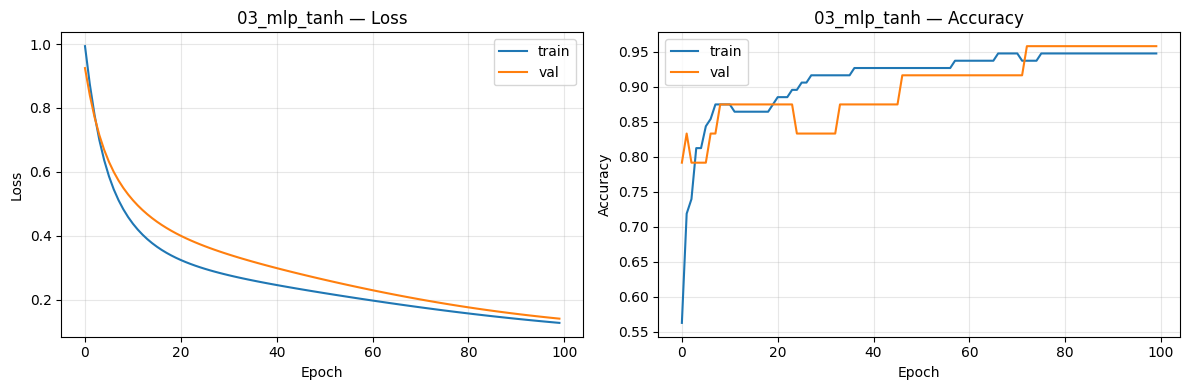

In [17]:
plot_training_curves(history, variant_name='03_mlp_tanh')


## 7. Evaluasi di test set

In [18]:
summary = evaluate_and_report(model, X_test, y_test, variant_name='03_mlp_tanh')
save_history(history, variant_name='03_mlp_tanh')
summary



📊 03_mlp_tanh
   Test loss:     0.1415
   Test accuracy: 0.9667
   Jumlah parameter: 131
✅ History tersimpan di: results/03_mlp_tanh.csv


{'variant': '03_mlp_tanh',
 'test_loss': 0.14148029685020447,
 'test_accuracy': 0.9666666388511658,
 'n_params': 131}

## 8. Refleksi singkat
_Diisi oleh anggota yang mengerjakan notebook ini._ Tuliskan jawaban dalam cell markdown di bawah:

1. Slide 2.7 mengklaim Tanh 'mempercepat pembelajaran karena zero-centered'. Apakah klaim ini terbukti pada hasilmu (bandingkan dengan Varian 02 — Sigmoid)?
2. Coba bandingkan epoch ke berapa Varian 02 dan Varian 03 mencapai val_accuracy ≥ 0.90.
3. Menurutmu, kenapa zero-centered penting untuk gradient descent?


[link text](https://)_Tulis jawabanmu di sini..._

1. Iya, lebih cepat.
2. Varian 02 - Epoch 35, Varian 03 - Epoch 48
3. Untuk menjaga pergerakan gradient descent tetap stabil, efisien, dan mencegah gradien menghilang (vanishing gradients).